In [134]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

In [170]:
import pandas as pd

# Read CSV
preference_returns = pd.read_csv("Preference Returns.csv", index_col="date")

# # Convert index to datetime if not already
# preference_returns.index = pd.to_datetime(preference_returns.index, errors='coerce')
#
# # Convert to monthly period and then to month-end timestamps
# preference_returns.index = preference_returns.index.to_period('M').to_timestamp('M')
#
# # Check
preference_returns.head()


,Preference Return
date,
1960-01-29,-0.018005
1960-02-29,0.009621
1960-03-31,0.015161
1960-04-29,0.002178
1960-05-31,0.012071


In [171]:
sp500 = pd.read_csv("sp500_returns_with_tickers.csv", index_col="date")

In [172]:
combined = sp500.join(preference_returns, how="inner")

In [152]:
cap_data = pd.read_csv("sp500_market_caps.csv", index_col="date")
cap_data.head()
cap_data = cap_data * 1000
cap_data.tail()
len(cap_data.columns)
cap_data_numeric = cap_data.apply(pd.to_numeric, errors='coerce')
cap_data_numeric = cap_data_numeric.fillna(0)
weight_data = cap_data_numeric.div(cap_data_numeric.sum(axis=1), axis=0)
row_sums = weight_data.sum(axis=1)
print(row_sums.head())
weight_data.head(100)

date
1960-01-29    1.0
1960-02-29    1.0
1960-03-31    1.0
1960-04-29    1.0
1960-05-31    1.0
dtype: float64


,ACF,ABK,AMT,JAVA,AN,ORCL,MSFT,SDS,AYE,TROW,...,CFN,AVGO,VRSK,DG.2,FTNT,VAL,GNRC,QEP,CBOE,TSLA
date,,,,,,,,,,,,,,,,,,,,,
1960-01-29,0.000291,0.000336,0.000111,0.0,0.001253,0.0,0.0,0.0,0.001330,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1960-02-29,0.000297,0.000339,0.000110,0.0,0.001204,0.0,0.0,0.0,0.001387,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1960-03-31,0.000284,0.000305,0.000107,0.0,0.001269,0.0,0.0,0.0,0.001384,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1960-04-29,0.000265,0.000293,0.000109,0.0,0.001226,0.0,0.0,0.0,0.001422,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1960-05-31,0.000267,0.000277,0.000101,0.0,0.001217,0.0,0.0,0.0,0.001444,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1967-12-29,0.000552,0.000232,0.000096,0.0,0.000837,0.0,0.0,0.0,0.000936,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1968-01-31,0.000552,0.000250,0.000102,0.0,0.000843,0.0,0.0,0.0,0.001010,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1968-02-29,0.000542,0.000260,0.000100,0.0,0.000818,0.0,0.0,0.0,0.001060,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [174]:
stock_counts = (cap_data > 0).sum(axis=1)

# Divide 1 by number of available stocks to assign equal weights
equal_weight_data = cap_data.copy()
equal_weight_data[:] = 0  # reset
for col in cap_data.columns:
    equal_weight_data[col] = (cap_data[col] > 0).astype(int).div(stock_counts, axis=0)

print("Equal-weighted row sums:")
print(equal_weight_data.sum(axis=1).head())

Equal-weighted row sums:
date
1960-01-29    1.0
1960-02-29    1.0
1960-03-31    1.0
1960-04-29    1.0
1960-05-31    1.0
dtype: float64


In [176]:
preference_weights = weight_data - equal_weight_data
preference_weights.tail()

,ACF,ABK,AMT,JAVA,AN,ORCL,MSFT,SDS,AYE,TROW,...,CFN,AVGO,VRSK,DG.2,FTNT,VAL,GNRC,QEP,CBOE,TSLA
date,,,,,,,,,,,,,,,,,,,,,
2024-08-30,0.0,0.0,0.0,0.0,0.0,0.005898,0.060810,0.0,0.0,-0.001510,...,0.0,0.013414,-0.001201,-0.001619,-0.000800,0.0,-0.001797,0.0,-0.001553,0.011865
2024-09-30,0.0,0.0,0.0,0.0,0.0,0.007358,0.061306,0.0,0.0,-0.001505,...,0.0,0.013956,-0.001235,-0.001616,-0.000809,0.0,-0.001795,0.0,-0.001560,0.014616
2024-10-31,0.0,0.0,0.0,0.0,0.0,0.007308,0.058396,0.0,0.0,-0.001500,...,0.0,0.013860,-0.001213,-0.001636,-0.000784,0.0,-0.001789,0.0,-0.001541,0.014042
2024-11-29,0.0,0.0,0.0,0.0,0.0,0.007676,0.057414,0.0,0.0,-0.001469,...,0.0,0.012342,-0.001204,-0.001667,-0.000614,0.0,-0.001777,0.0,-0.001562,0.018917
2024-12-31,0.0,0.0,0.0,0.0,0.0,0.006998,0.058433,0.0,0.0,-0.001504,...,0.0,0.018958,-0.001238,-0.001667,-0.000592,0.0,-0.001810,0.0,-0.001594,0.023006


In [205]:
# Long-only mask
long_mask = (preference_weights > 0).astype(int)

# Short-only mask
short_mask = (preference_weights < 0).astype(int)

long_mask

,ACF,ABK,AMT,JAVA,AN,ORCL,MSFT,SDS,AYE,TROW,...,CFN,AVGO,VRSK,DG.2,FTNT,VAL,GNRC,QEP,CBOE,TSLA
date,,,,,,,,,,,,,,,,,,,,,
1960-01-29,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1960-02-29,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1960-03-31,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1960-04-29,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1960-05-31,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-30,0,0,0,0,0,1,1,0,0,0,...,0,1,0,0,0,0,0,0,0,1
2024-09-30,0,0,0,0,0,1,1,0,0,0,...,0,1,0,0,0,0,0,0,0,1
2024-10-31,0,0,0,0,0,1,1,0,0,0,...,0,1,0,0,0,0,0,0,0,1


In [187]:
FACTOR_COL = "Preference Return"
MIN_OBS = 10
ROLLING_WINDOW = 36

In [188]:
sp500.index = pd.to_datetime(sp500.index)
preference_returns.index = pd.to_datetime(preference_returns.index)


combined = sp500.join(preference_returns, how="inner")
asset_cols = sp500.columns

In [189]:
print(preference_returns.index[:10])
print(sp500.index[:10])



DatetimeIndex(['1960-01-29', '1960-02-29', '1960-03-31', '1960-04-29',
               '1960-05-31', '1960-06-30', '1960-07-29', '1960-08-31',
               '1960-09-30', '1960-10-31'],
              dtype='datetime64[ns]', name='date', freq=None)
DatetimeIndex(['1960-01-29', '1960-02-29', '1960-03-31', '1960-04-29',
               '1960-05-31', '1960-06-30', '1960-07-29', '1960-08-31',
               '1960-09-30', '1960-10-31'],
              dtype='datetime64[ns]', name='date', freq=None)


In [156]:
betas_dict = {asset: [] for asset in asset_cols}
beta_dates = []

for end_date in combined.index[ROLLING_WINDOW-1:]:
    start_date = combined.index.get_loc(end_date) - (ROLLING_WINDOW - 1)
    window_dates = combined.index[start_date : start_date + ROLLING_WINDOW]


    for asset in asset_cols:

        y = sp500.loc[window_dates, asset]
        x = preference_returns.loc[window_dates, FACTOR_COL]
        data = pd.concat([y, x], axis=1).dropna()
        if len(data) < MIN_OBS:
            betas_dict[asset].append(np.nan)
            continue

        Y = data[asset]
        X = sm.add_constant(data[FACTOR_COL])

        res = sm.OLS(Y, X).fit()
        betas_dict[asset].append(res.params[FACTOR_COL])

    beta_dates.append(end_date)

betas_df = pd.DataFrame(betas_dict, index=beta_dates)

In [157]:
betas_df.head()

,ACF,ABK,AMT,JAVA,AN,ORCL,MSFT,SDS,AYE,TROW,...,CFN,AVGO,VRSK,DG.2,FTNT,VAL,GNRC,QEP,CBOE,TSLA
1971-08-31,-1.951456,-2.525101,-1.574317,NaN,-2.063905,NaN,NaN,NaN,-0.242303,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1971-09-30,-1.610799,-2.010116,-1.186677,NaN,-1.894683,NaN,NaN,NaN,-0.377787,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1971-11-30,-1.643634,-1.880655,-1.373477,NaN,-1.794333,NaN,NaN,NaN,-0.563746,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1971-12-31,-1.540915,-1.861851,-1.014426,NaN,-1.490182,NaN,NaN,NaN,-0.415873,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1972-01-31,-1.602757,-2.371373,-1.674557,NaN,-1.943998,NaN,NaN,NaN,-0.769949,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [194]:
lambda_vals, lambda_dates = [], []

for date in betas_df.index:

    if date not in sp500.index:
        continue
    returns_t = sp500.loc[date].dropna()
    betas_t = betas_df.loc[date].dropna()


    common_assets = returns_t.index.intersection(betas_t.index)

    y_cs = returns_t.loc[common_assets]
    X_cs = sm.add_constant(betas_t.loc[common_assets])

    if len(y_cs) < MIN_OBS:
        continue

    res_cs = sm.OLS(y_cs, X_cs).fit()

    lambda_vals.append(res_cs.params[1])
    lambda_dates.append(date)

lambda_series = pd.Series(lambda_vals, index=lambda_dates, name="lambda_t")

KeyError: Timestamp('1971-08-31 00:00:00')

In [209]:
sp500.index = pd.to_datetime(sp500.index)
betas_df.index = pd.to_datetime(betas_df.index)
weight_data.index = pd.to_datetime(weight_data.index)
long_mask.index = pd.to_datetime(long_mask.index)
short_mask.index = pd.to_datetime(short_mask.index)

def run_two_pass(sp500, preference_returns, betas_df, mask, MIN_OBS=10):
    lambda_vals, lambda_dates = [], []

    for date in betas_df.index:
        if date not in sp500.index:
            continue

        returns_t = sp500.loc[date].dropna()
        betas_t = betas_df.loc[date].dropna()

        common_assets = returns_t.index.intersection(betas_t.index)
        common_assets = common_assets.intersection(mask.loc[date][mask.loc[date] == 1].index)

        if len(common_assets) < MIN_OBS:
            continue

        y_cs = returns_t.loc[common_assets]
        X_cs = sm.add_constant(betas_t.loc[common_assets])

        res_cs = sm.OLS(y_cs, X_cs).fit()

        lambda_vals.append(res_cs.params[1])
        lambda_dates.append(date)

    return pd.Series(lambda_vals, index=lambda_dates, name="lambda_t")

lambda_series = run_two_pass(sp500, preference_returns, betas_df, long_mask)
# lambda_short = run_two_pass(sp500, preference_returns, betas_df, short_mask)
lambda_series

/var/folders/rd/6pjhbndj3_xbc_vx64hj0zh00000gn/T/ipykernel_80991/1997602152.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda_vals.append(res_cs.params[1])
/var/folders/rd/6pjhbndj3_xbc_vx64hj0zh00000gn/T/ipykernel_80991/1997602152.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda_vals.append(res_cs.params[1])
/var/folders/rd/6pjhbndj3_xbc_vx64hj0zh00000gn/T/ipykernel_80991/1997602152.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by positio

1971-08-31    0.007635
1971-09-30    0.007293
1971-11-30    0.005976
1971-12-31    0.003212
1972-01-31   -0.005374
                ...   
2024-05-31    0.013597
2024-07-31   -0.028294
2024-09-30    0.007934
2024-10-31   -0.003710
2024-12-31    0.029951
Name: lambda_t, Length: 451, dtype: float64

In [105]:
#weighted least squares regresssion

lambda_vals, lambda_dates = [], []


sp500.index = pd.to_datetime(sp500.index)
betas_df.index = pd.to_datetime(betas_df.index)
weight_data.index = pd.to_datetime(weight_data.index)

for date in betas_df.index:

    returns_t = sp500.reindex([date]).iloc[0].dropna()
    betas_t = betas_df.reindex([date]).iloc[0].dropna()


    w = weight_data.reindex([date]).fillna(0).iloc[0]


    common_assets = returns_t.index.intersection(betas_t.index).intersection(w.index)
    if len(common_assets) < MIN_OBS:
        continue

    y_cs = returns_t.loc[common_assets]
    X_cs = sm.add_constant(betas_t.loc[common_assets])
    w_cs = w.loc[common_assets]


    res_cs_wls = sm.WLS(y_cs, X_cs, weights=w_cs).fit()
    lambda_vals.append(res_cs_wls.params[1])
    lambda_dates.append(date)

lambda_series = pd.Series(lambda_vals, index=lambda_dates, name="lambda_t")

/var/folders/rd/6pjhbndj3_xbc_vx64hj0zh00000gn/T/ipykernel_80991/3811917217.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda_vals.append(res_cs_wls.params[1])
/var/folders/rd/6pjhbndj3_xbc_vx64hj0zh00000gn/T/ipykernel_80991/3811917217.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda_vals.append(res_cs_wls.params[1])
/var/folders/rd/6pjhbndj3_xbc_vx64hj0zh00000gn/T/ipykernel_80991/3811917217.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by

In [210]:
mean_lambda = lambda_series.mean()
std_lambda = lambda_series.std(ddof=1)
t_stat = mean_lambda / (std_lambda / np.sqrt(len(lambda_series)))

print("\n----- Fama–MacBeth summary -----")
print(f"Mean λ (risk premium):  {mean_lambda:.6f}")
print(f"T-statistic:            {t_stat:.3f}")


----- Fama–MacBeth summary -----
Mean λ (risk premium):  0.000212
T-statistic:            0.217


In [211]:
lambda_series

1971-08-31    0.007635
1971-09-30    0.007293
1971-11-30    0.005976
1971-12-31    0.003212
1972-01-31   -0.005374
                ...   
2024-05-31    0.013597
2024-07-31   -0.028294
2024-09-30    0.007934
2024-10-31   -0.003710
2024-12-31    0.029951
Name: lambda_t, Length: 451, dtype: float64

In [212]:
ROLLING_T_WINDOW = 24

rolling_results = []
for i in range(len(lambda_series) - ROLLING_T_WINDOW + 1):
    window_lambdas = lambda_series.iloc[i : i + ROLLING_T_WINDOW]
    mean_l = window_lambdas.mean()
    std_l = window_lambdas.std(ddof=1)
    t_l = mean_l / (std_l / np.sqrt(len(window_lambdas)))
    rolling_results.append({
        "end_date": window_lambdas.index[-1],
        "mean_lambda": mean_l,
        "t_stat": t_l
    })

rolling_df = pd.DataFrame(rolling_results).set_index("end_date")

print(rolling_df.tail())


            mean_lambda    t_stat
end_date                         
2024-05-31     0.002991  0.631088
2024-07-31     0.000684  0.142776
2024-09-30     0.002085  0.447572
2024-10-31     0.003633  0.848605
2024-12-31     0.005619  1.303568


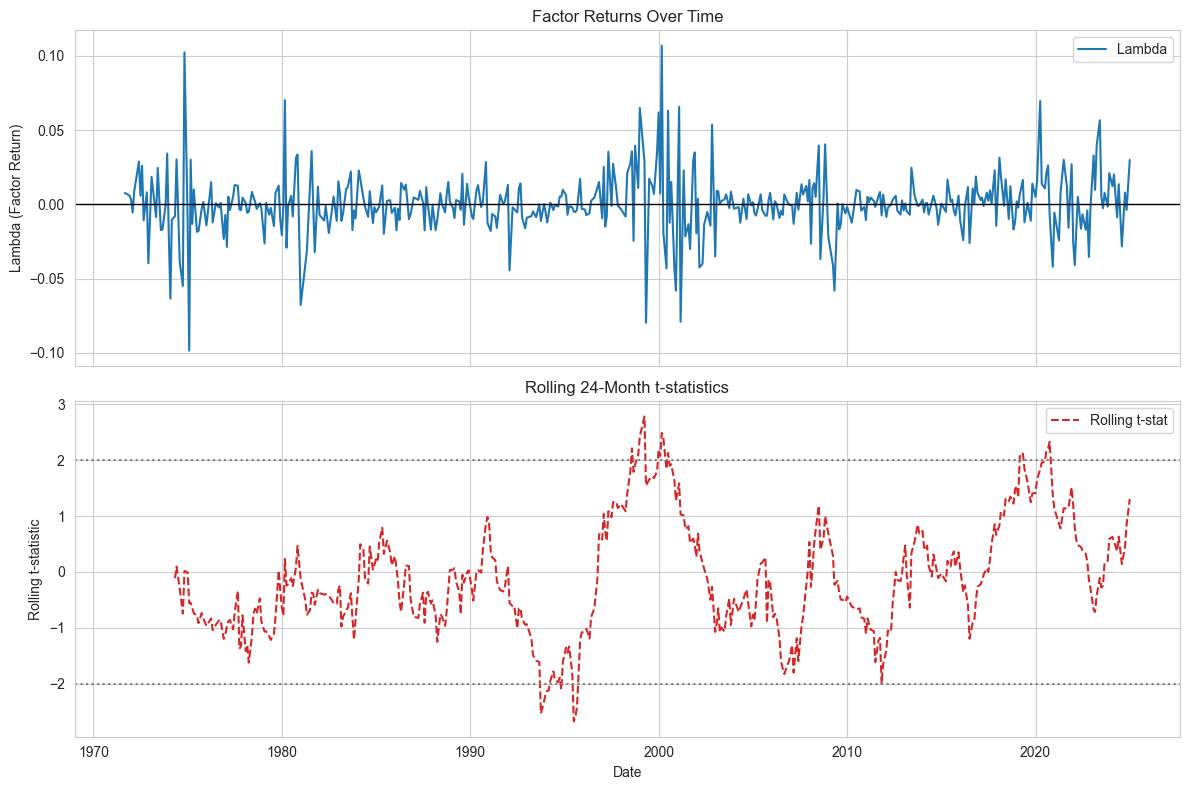

In [213]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,8), sharex=True)

# Top plot: Lambda over time
ax1.plot(lambda_series.index, lambda_series, color="tab:blue", label="Lambda")
ax1.set_ylabel("Lambda (Factor Return)")
ax1.axhline(0, color="black", linewidth=1)
ax1.set_title("Factor Returns Over Time")
ax1.legend()

# Bottom plot: Rolling t-statistics
ax2.plot(rolling_df.index, rolling_df["t_stat"], color="tab:red", linestyle="--", label="Rolling t-stat")
ax2.axhline(2, color="gray", linestyle="dotted")
ax2.axhline(-2, color="gray", linestyle="dotted")
ax2.set_ylabel("Rolling t-statistic")
ax2.set_xlabel("Date")
ax2.set_title(f"Rolling {ROLLING_T_WINDOW}-Month t-statistics")
ax2.legend()

plt.tight_layout()
plt.show()


/var/folders/rd/6pjhbndj3_xbc_vx64hj0zh00000gn/T/ipykernel_80991/1793803850.py:30: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = res_cs.params[1]
/var/folders/rd/6pjhbndj3_xbc_vx64hj0zh00000gn/T/ipykernel_80991/1793803850.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept = res_cs.params[0]


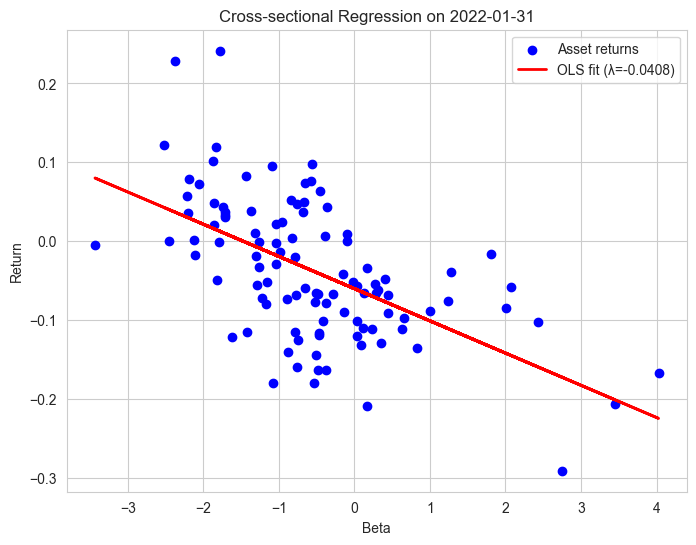

/var/folders/rd/6pjhbndj3_xbc_vx64hj0zh00000gn/T/ipykernel_80991/1793803850.py:30: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = res_cs.params[1]
/var/folders/rd/6pjhbndj3_xbc_vx64hj0zh00000gn/T/ipykernel_80991/1793803850.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept = res_cs.params[0]


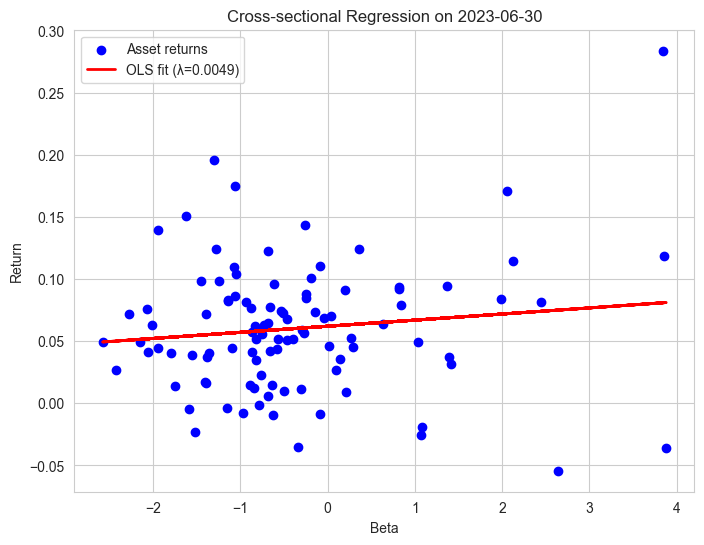

2009-01-30 not in dataset, skipping.


In [214]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

# List of dates you want to plot (make sure they are in your index)
dates_to_plot = [
    pd.Timestamp("2022-01-31"),
    pd.Timestamp("2023-06-30"),
    pd.Timestamp("2009-01-30")
]

for date_to_plot in dates_to_plot:
    if date_to_plot not in lambda_series.index:
        print(f"{date_to_plot.date()} not in dataset, skipping.")
        continue

    # Returns and betas for that date
    returns_t = sp500.loc[date_to_plot].dropna()
    betas_t = betas_df.loc[date_to_plot].dropna()

    # Keep only assets with both return and beta
    common_assets = returns_t.index.intersection(betas_t.index)
    common_assets = [asset for asset in common_assets if long_mask.loc[date_to_plot, asset] == 1]

    y_cs = returns_t.loc[common_assets]
    X_cs = betas_t.loc[common_assets]

    # Fit cross-sectional regression
    X_with_const = sm.add_constant(X_cs)
    res_cs = sm.OLS(y_cs, X_with_const).fit()
    slope = res_cs.params[1]
    intercept = res_cs.params[0]

    # Scatter plot
    plt.figure(figsize=(8,6))
    plt.scatter(X_cs, y_cs, color='blue', label='Asset returns')
    plt.plot(X_cs, intercept + slope*X_cs, color='red', linewidth=2, label=f'OLS fit (λ={slope:.4f})')
    plt.xlabel("Beta")
    plt.ylabel("Return")
    plt.title(f"Cross-sectional Regression on {date_to_plot.date()}")
    plt.legend()
    plt.grid(True)
    plt.show()



/var/folders/rd/6pjhbndj3_xbc_vx64hj0zh00000gn/T/ipykernel_80991/4114630763.py:30: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = res_cs.params[1]
/var/folders/rd/6pjhbndj3_xbc_vx64hj0zh00000gn/T/ipykernel_80991/4114630763.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept = res_cs.params[0]


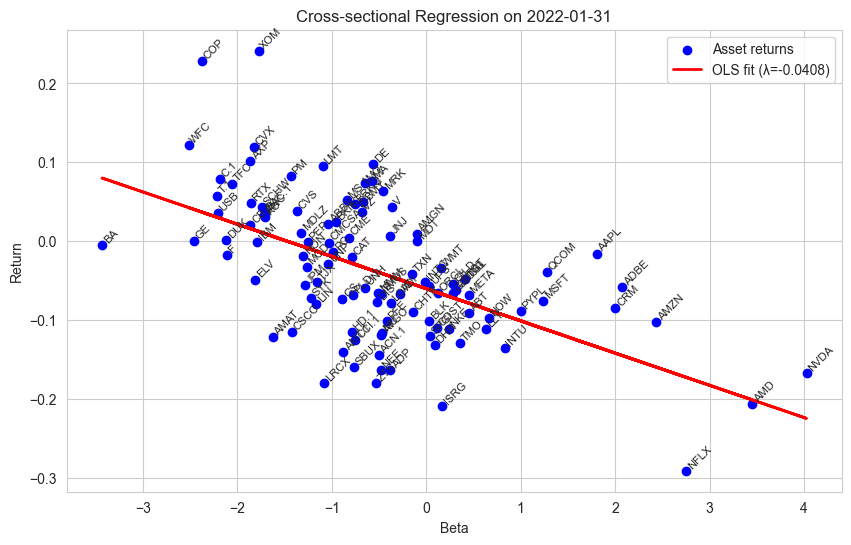

/var/folders/rd/6pjhbndj3_xbc_vx64hj0zh00000gn/T/ipykernel_80991/4114630763.py:30: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = res_cs.params[1]
/var/folders/rd/6pjhbndj3_xbc_vx64hj0zh00000gn/T/ipykernel_80991/4114630763.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept = res_cs.params[0]


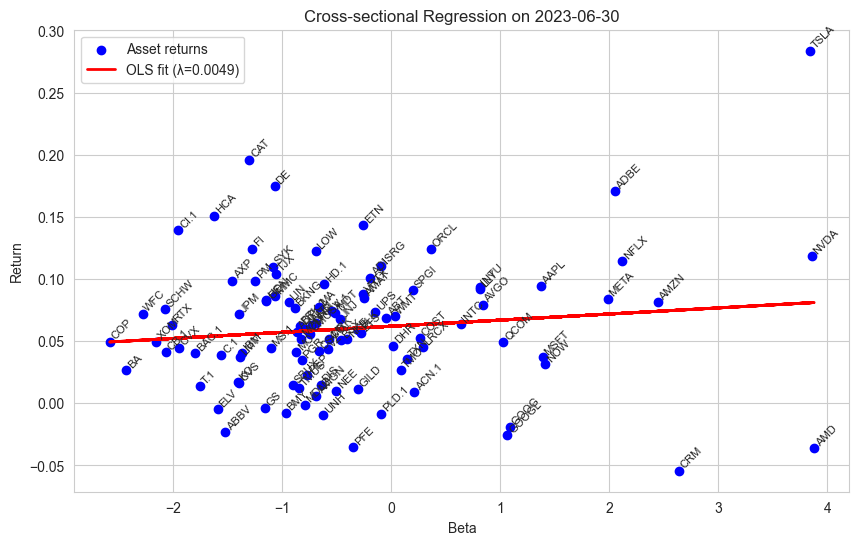

/var/folders/rd/6pjhbndj3_xbc_vx64hj0zh00000gn/T/ipykernel_80991/4114630763.py:30: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = res_cs.params[1]
/var/folders/rd/6pjhbndj3_xbc_vx64hj0zh00000gn/T/ipykernel_80991/4114630763.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept = res_cs.params[0]


2009-01-30 not in dataset, skipping.


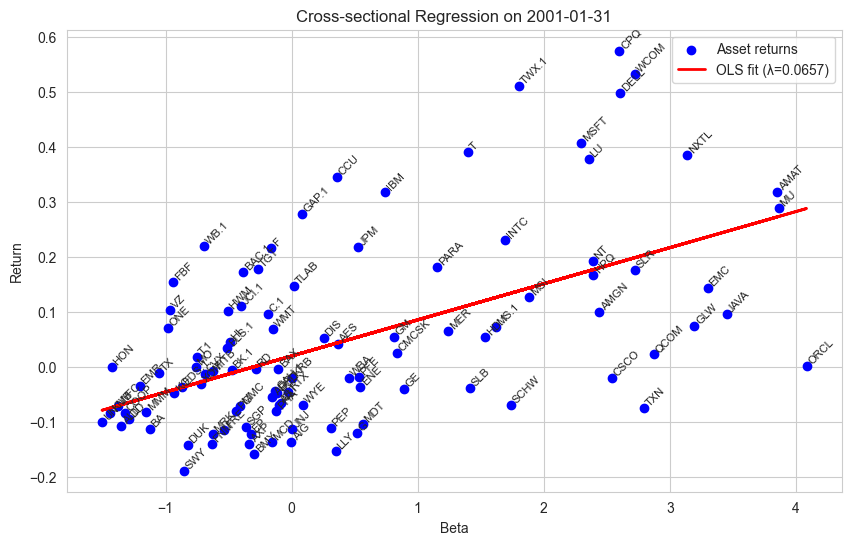

In [215]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

# List of dates you want to plot (make sure they are in your index)
dates_to_plot = [
    pd.Timestamp("2022-01-31"),
    pd.Timestamp("2023-06-30"),
    pd.Timestamp("2009-01-30"),
    pd.Timestamp("2001-01-31")
]

for date_to_plot in dates_to_plot:
    if date_to_plot not in lambda_series.index:
        print(f"{date_to_plot.date()} not in dataset, skipping.")
        continue

    # Returns and betas for that date
    returns_t = sp500.loc[date_to_plot].dropna()
    betas_t = betas_df.loc[date_to_plot].dropna()

    # Keep only assets with both return and beta
    common_assets = returns_t.index.intersection(betas_t.index)
    common_assets = [asset for asset in common_assets if long_mask.loc[date_to_plot, asset] == 1]
    y_cs = returns_t.loc[common_assets]
    X_cs = betas_t.loc[common_assets]

    # Fit cross-sectional regression
    X_with_const = sm.add_constant(X_cs)
    res_cs = sm.OLS(y_cs, X_with_const).fit()
    slope = res_cs.params[1]
    intercept = res_cs.params[0]

    # Scatter plot
    plt.figure(figsize=(10,6))
    plt.scatter(X_cs, y_cs, color='blue', label='Asset returns')

    # Add asset labels on top of points
    for asset, x, y in zip(common_assets, X_cs, y_cs):
        plt.text(x, y + 0.0005, asset, fontsize=8, rotation=45, ha='left', va='bottom')

    # Regression line
    plt.plot(X_cs, intercept + slope*X_cs, color='red', linewidth=2, label=f'OLS fit (λ={slope:.4f})')

    plt.xlabel("Beta")
    plt.ylabel("Return")
    plt.title(f"Cross-sectional Regression on {date_to_plot.date()}")
    plt.legend()
    plt.grid(True)
    plt.show()


/var/folders/rd/6pjhbndj3_xbc_vx64hj0zh00000gn/T/ipykernel_80991/1966246115.py:37: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = res_cs.params[1]
/var/folders/rd/6pjhbndj3_xbc_vx64hj0zh00000gn/T/ipykernel_80991/1966246115.py:38: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept = res_cs.params[0]


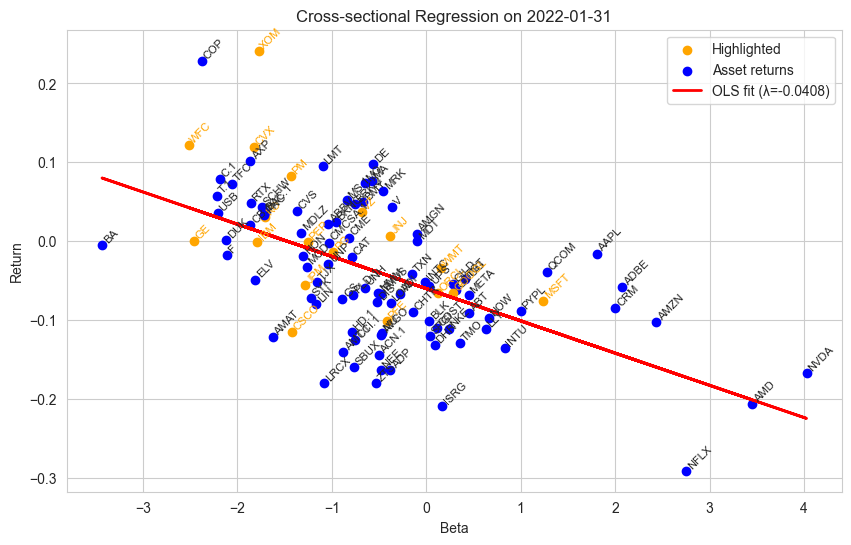

/var/folders/rd/6pjhbndj3_xbc_vx64hj0zh00000gn/T/ipykernel_80991/1966246115.py:37: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = res_cs.params[1]
/var/folders/rd/6pjhbndj3_xbc_vx64hj0zh00000gn/T/ipykernel_80991/1966246115.py:38: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept = res_cs.params[0]


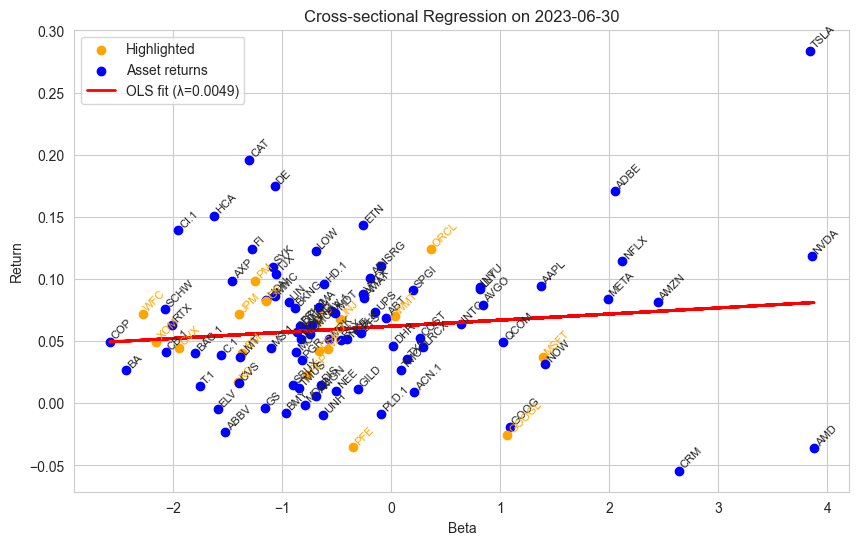

2009-01-30 not in dataset, skipping.


/var/folders/rd/6pjhbndj3_xbc_vx64hj0zh00000gn/T/ipykernel_80991/1966246115.py:37: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = res_cs.params[1]
/var/folders/rd/6pjhbndj3_xbc_vx64hj0zh00000gn/T/ipykernel_80991/1966246115.py:38: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept = res_cs.params[0]


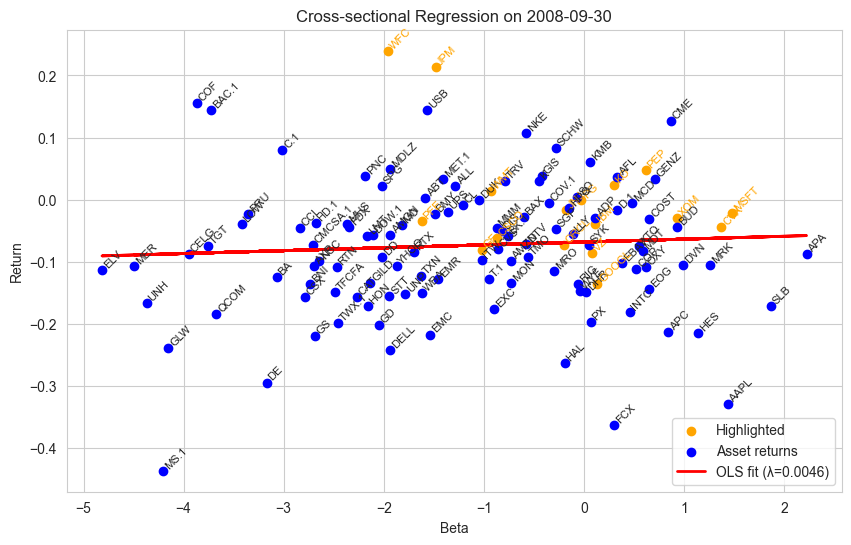

In [216]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

# List of dates you want to plot (make sure they are in your index)
dates_to_plot = [
    pd.Timestamp("2022-01-31"),
    pd.Timestamp("2023-06-30"),
    pd.Timestamp("2009-01-30"),
    pd.Timestamp("2008-09-30")
]

# Define tickers to highlight
highlight_tickers = [
    "XOM", "WMT", "PG", "MSFT", "JNJ", "BRK-B", "CVX", "T", "JPM",
    "PFE", "IBM", "KO", "GE", "WFC", "GOOGL", "CSCO", "VZ", "ORCL",
    "PM", "PEP"
]

for date_to_plot in dates_to_plot:
    if date_to_plot not in lambda_series.index:
        print(f"{date_to_plot.date()} not in dataset, skipping.")
        continue

    # Returns and betas for that date
    returns_t = sp500.loc[date_to_plot].dropna()
    betas_t = betas_df.loc[date_to_plot].dropna()

    # Keep only assets with both return and beta
    common_assets = returns_t.index.intersection(betas_t.index)
    common_assets = [asset for asset in common_assets if long_mask.loc[date_to_plot, asset] == 1]
    y_cs = returns_t.loc[common_assets]
    X_cs = betas_t.loc[common_assets]

    # Fit cross-sectional regression
    X_with_const = sm.add_constant(X_cs)
    res_cs = sm.OLS(y_cs, X_with_const).fit()
    slope = res_cs.params[1]
    intercept = res_cs.params[0]

    # Scatter plot
    plt.figure(figsize=(10,6))

    for asset, x, y in zip(common_assets, X_cs, y_cs):
        if asset in highlight_tickers:
            plt.scatter(x, y, color='orange', label='Highlighted' if 'Highlighted' not in plt.gca().get_legend_handles_labels()[1] else "")
            plt.text(x, y + 0.0005, asset, fontsize=8, rotation=45, ha='left', va='bottom', color='orange')
        else:
            plt.scatter(x, y, color='blue', label='Asset returns' if 'Asset returns' not in plt.gca().get_legend_handles_labels()[1] else "")
            plt.text(x, y + 0.0005, asset, fontsize=8, rotation=45, ha='left', va='bottom')

    # Regression line
    plt.plot(X_cs, intercept + slope*X_cs, color='red', linewidth=2, label=f'OLS fit (λ={slope:.4f})')

    plt.xlabel("Beta")
    plt.ylabel("Return")
    plt.title(f"Cross-sectional Regression on {date_to_plot.date()}")
    plt.legend()
    plt.grid(True)
    plt.show()


/var/folders/rd/6pjhbndj3_xbc_vx64hj0zh00000gn/T/ipykernel_80991/1625324142.py:30: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = res_cs.params[1]
/var/folders/rd/6pjhbndj3_xbc_vx64hj0zh00000gn/T/ipykernel_80991/1625324142.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept = res_cs.params[0]


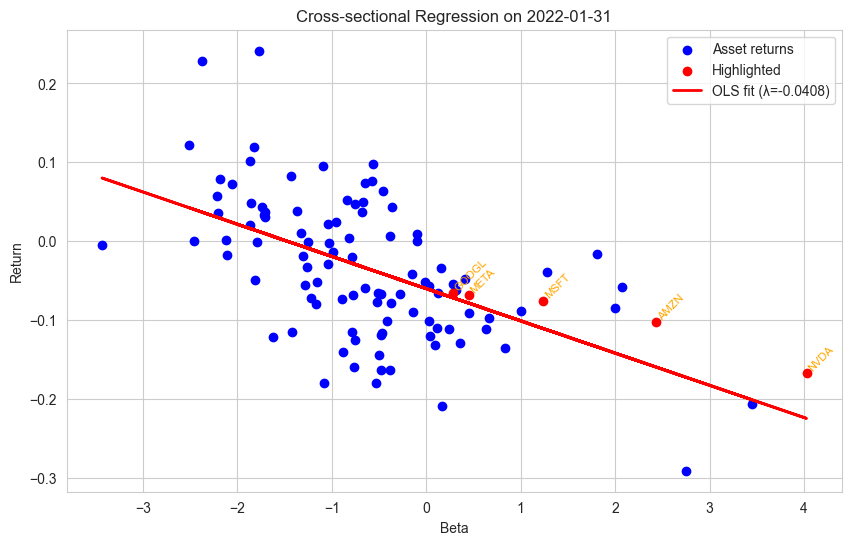

/var/folders/rd/6pjhbndj3_xbc_vx64hj0zh00000gn/T/ipykernel_80991/1625324142.py:30: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = res_cs.params[1]
/var/folders/rd/6pjhbndj3_xbc_vx64hj0zh00000gn/T/ipykernel_80991/1625324142.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept = res_cs.params[0]


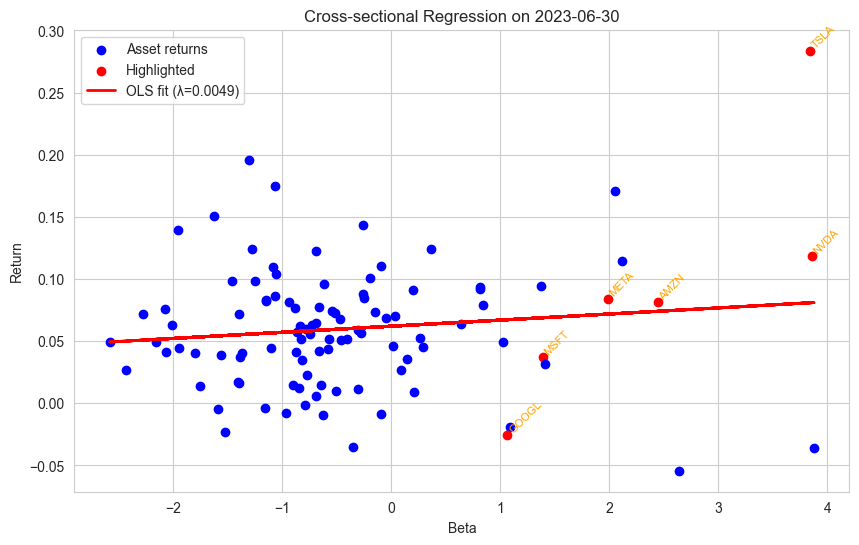

2009-01-30 not in dataset, skipping.
2008-08-29 not in dataset, skipping.


/var/folders/rd/6pjhbndj3_xbc_vx64hj0zh00000gn/T/ipykernel_80991/1625324142.py:30: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = res_cs.params[1]
/var/folders/rd/6pjhbndj3_xbc_vx64hj0zh00000gn/T/ipykernel_80991/1625324142.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept = res_cs.params[0]


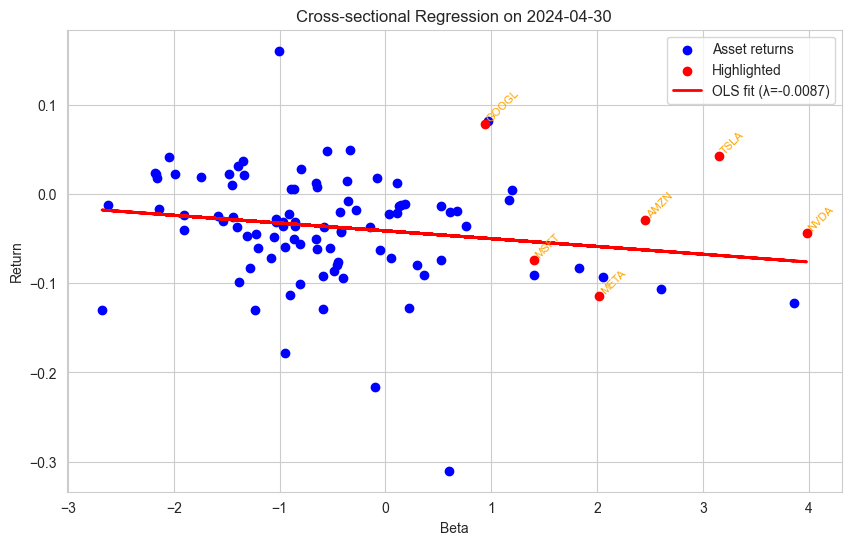

In [217]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

# List of dates you want to plot
dates_to_plot = [
    pd.Timestamp("2022-01-31"),
    pd.Timestamp("2023-06-30"),
    pd.Timestamp("2009-01-30"),
    pd.Timestamp("2008-08-29"),
    pd.Timestamp("2024-04-30")
]

# Define tickers to highlight
highlight_tickers = ["TSLA","MSFT","APPL","META","GOOGL","NVDA", "AMZN"]

for date_to_plot in dates_to_plot:
    if date_to_plot not in lambda_series.index:
        print(f"{date_to_plot.date()} not in dataset, skipping.")
        continue

    returns_t = sp500.loc[date_to_plot].dropna()
    betas_t = betas_df.loc[date_to_plot].dropna()
    common_assets = returns_t.index.intersection(betas_t.index)
    common_assets = [asset for asset in common_assets if long_mask.loc[date_to_plot, asset] == 1]
    y_cs = returns_t.loc[common_assets]
    X_cs = betas_t.loc[common_assets]

    X_with_const = sm.add_constant(X_cs)
    res_cs = sm.OLS(y_cs, X_with_const).fit()
    slope = res_cs.params[1]
    intercept = res_cs.params[0]

    plt.figure(figsize=(10,6))

    for asset, x, y in zip(common_assets, X_cs, y_cs):
        if asset in highlight_tickers:
            plt.scatter(x, y, color='red', label='Highlighted' if 'Highlighted' not in plt.gca().get_legend_handles_labels()[1] else "")
            plt.text(x, y + 0.0005, asset, fontsize=8, rotation=45, ha='left', va='bottom', color='orange')
        else:
            plt.scatter(x, y, color='blue', label='Asset returns' if 'Asset returns' not in plt.gca().get_legend_handles_labels()[1] else "")

    # Regression line
    plt.plot(X_cs, intercept + slope*X_cs, color='red', linewidth=2, label=f'OLS fit (λ={slope:.4f})')

    plt.xlabel("Beta")
    plt.ylabel("Return")
    plt.title(f"Cross-sectional Regression on {date_to_plot.date()}")
    plt.legend()
    plt.grid(True)
    plt.show()


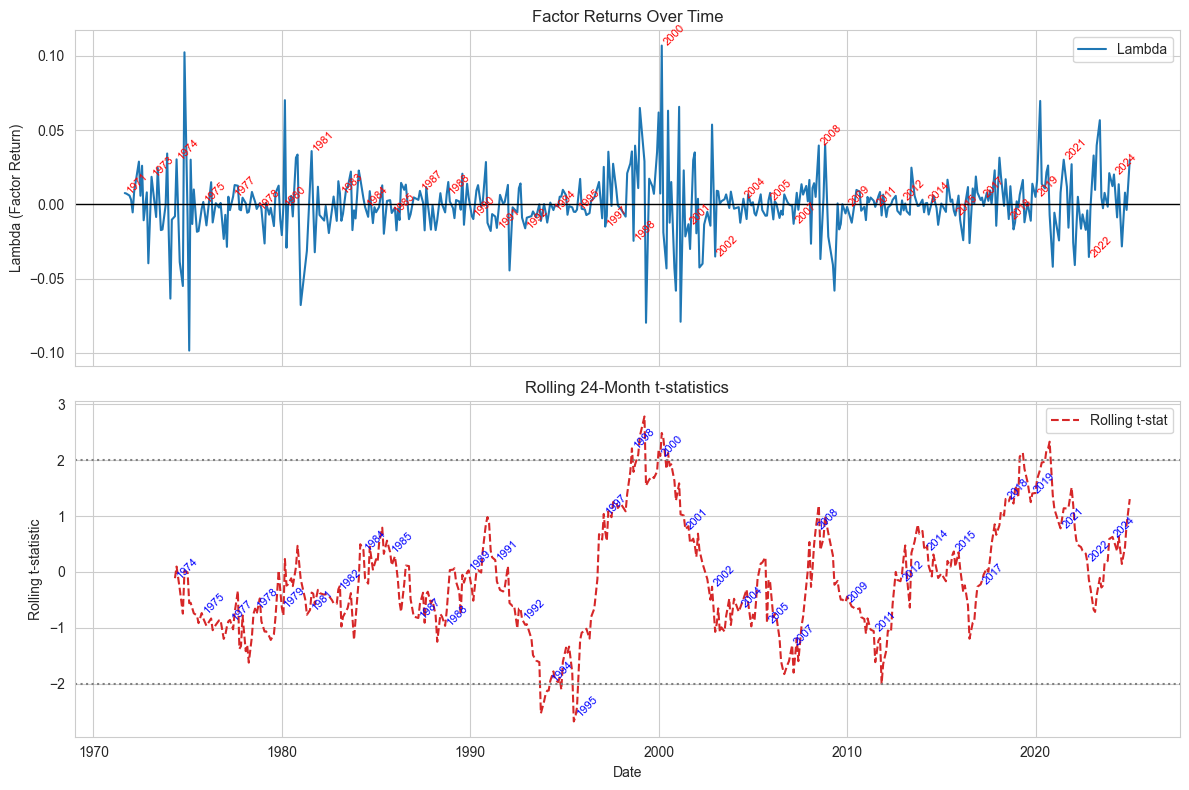

In [218]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,8), sharex=True)

# Top plot: Lambda over time
ax1.plot(lambda_series.index, lambda_series, color="tab:blue", label="Lambda")
ax1.set_ylabel("Lambda (Factor Return)")
ax1.axhline(0, color="black", linewidth=1)
ax1.set_title("Factor Returns Over Time")
ax1.legend()

# Annotate a few dates on top plot in contrasting color (e.g., dark green)
for i, date in enumerate(lambda_series.index):
    if i % 12 == 0:  # annotate every 12th point
        ax1.text(date, lambda_series.iloc[i], str(date.year), color='red', fontsize=8, rotation=45)

# Bottom plot: Rolling t-statistics
ax2.plot(rolling_df.index, rolling_df["t_stat"], color="tab:red", linestyle="--", label="Rolling t-stat")
ax2.axhline(2, color="gray", linestyle="dotted")
ax2.axhline(-2, color="gray", linestyle="dotted")
ax2.set_ylabel("Rolling t-statistic")
ax2.set_xlabel("Date")
ax2.set_title(f"Rolling {ROLLING_T_WINDOW}-Month t-statistics")
ax2.legend()

# Annotate a few dates on bottom plot in contrasting color (e.g., purple)
for i, date in enumerate(rolling_df.index):
    if i % 12 == 0:  # annotate every 12th point
        ax2.text(date, rolling_df["t_stat"].iloc[i], str(date.year), color='blue', fontsize=8, rotation=45)

plt.tight_layout()
plt.show()
